# EccoPy-2D-H Workflow

EccoPy-2D-H classifies a **single horizontal level or composite**
(Y x X — e.g. a CAPPI, a column-max composite) into echo type. Unlike
EccoPy-2D-V/3D, there is no vertical axis here, so no sub-classification
into shallow/mid/deep is possible — output is always the basic 3-code
classification.

EccoPy-2D-H uses the **same 2-D radial texture + planar-detrend +
dual-threshold clumping** engine as EccoPy-3D (just on a single level),
rather than EccoPy-1D/2D-V's 1-D sliding-window texture.

This notebook is self-contained (synthetic data, no external files) and
walks through:

1. Generating a synthetic composite
2. `WindowSpec` for a 2-D radial (circular) neighbourhood
3. `TextureParams` / `ClassificationParams` and `min_convective_area`
4. Debugging with `return_intermediates=True` (note: this path is SLOW)
5. Statistics with `eccopy.stats`
6. Plotting with `plot_result()` and EccoPy's colormaps


In [1]:
import sys
from pathlib import Path

# Walk up from the notebook's location until we find the directory
# containing the `eccopy` package folder, then add it to sys.path.
here = Path.cwd()
for candidate in [here, *here.parents]:
    if (candidate / "eccopy").is_dir():
        sys.path.insert(0, str(candidate))
        break

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
np.set_printoptions(precision=3, suppress=True)


In [2]:
from eccopy import eccopy2d_h, stats
from eccopy.params import WindowSpec, TextureParams, ClassificationParams
from eccopy.eccopy2d_h.plot import plot_result
from eccopy.core.colormaps import (
    basic_echo_type_cmap, basic_echo_type_norm, BASIC_ECHO_TYPE_LABELS,
    convectivity_cmap, convectivity_norm,
)

## 1. Generate a synthetic composite

A (Y, X) = (60, 80) composite: a broad stratiform shield with two
embedded convective cells of different sizes.


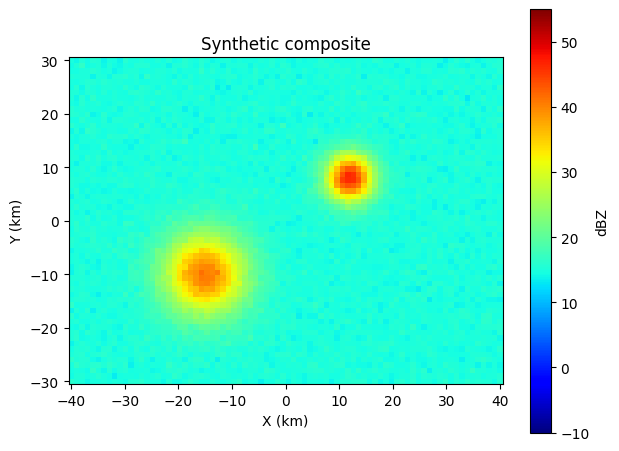

In [3]:
np.random.seed(3)
ny, nx = 60, 80
y_km = np.linspace(-30, 30, ny)
x_km = np.linspace(-40, 40, nx)
yy, xx = np.meshgrid(y_km, x_km, indexing="ij")

dbz = 15 + np.random.normal(0, 0.6, (ny, nx))
cell_a = 32 * np.exp(-((yy - 8) ** 2 + (xx - 12) ** 2) / 20)     # small, intense cell
cell_b = 26 * np.exp(-((yy + 10) ** 2 + (xx + 15) ** 2) / 60)    # larger, broader cell
dbz += cell_a + cell_b
dbz = np.clip(dbz, -20, 60)

fig, ax = plt.subplots(figsize=(7, 5.5))
pc = ax.pcolormesh(x_km, y_km, dbz, cmap="jet", vmin=-10, vmax=55, shading="auto")
plt.colorbar(pc, ax=ax, label="dBZ")
ax.set(xlabel="X (km)", ylabel="Y (km)", title="Synthetic composite")
ax.set_aspect("equal")
plt.show()

## 2. `WindowSpec` for a 2-D radial neighbourhood

EccoPy-2D-H uses a **circular** neighbourhood radius (matching
EccoPy-3D's per-level texture), not a 1-D sliding window.
`WindowSpec((7, "km"))` (the default) means a 7 km radius circle around
each point; a plain float or int is accepted directly as a km radius too.


Codes present: [np.int64(1), np.int64(2), np.int64(3)]
n_clumps: 2


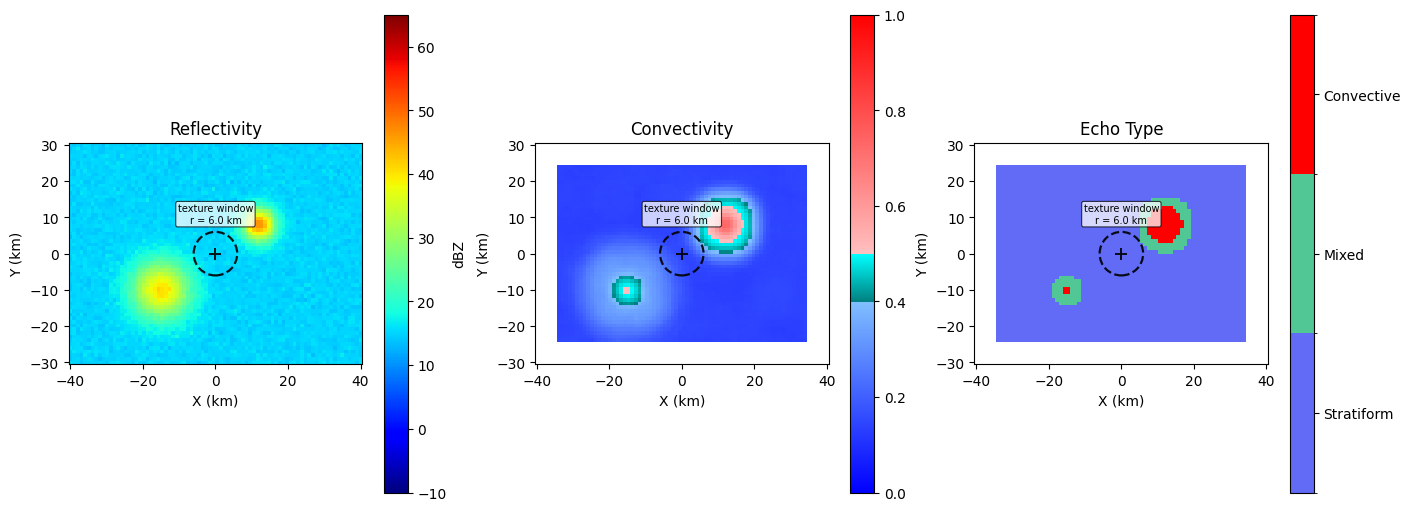

In [4]:
window = WindowSpec((6, "km"))
r = eccopy2d_h.run(dbz, coords_y=y_km, coords_x=x_km, window=window)

print("Codes present:", sorted(np.unique(r.echo_type[~np.isnan(r.echo_type)]).astype(int)))
print("n_clumps:", r.n_clumps)
fig = plot_result(r, dbz, coords_y=y_km, coords_x=x_km)

## 3. `TextureParams`, `ClassificationParams`, and `min_convective_area`

Same `TextureParams`/`ClassificationParams` fields as the other modules.
EccoPy-2D-H additionally accepts `min_convective_area` (km²): any
clump smaller than this is demoted from Convective to Mixed. It
defaults to `None` (no size floor) — there's no validated default for
composite data yet, same convention as EccoPy-1D's
`min_convective_length`.


In [5]:
r_no_floor = eccopy2d_h.run(dbz, coords_y=y_km, coords_x=x_km, window=window)
r_area_floor = eccopy2d_h.run(dbz, coords_y=y_km, coords_x=x_km, window=window,
                              min_convective_area=15.0)   # km^2

print("No area floor    -- n_clumps: %d, conv%%: %.1f" %
      (r_no_floor.n_clumps, stats.convective_percentage(r_no_floor.echo_type)))
print("15 km^2 floor    -- n_clumps: %d, conv%%: %.1f" %
      (r_area_floor.n_clumps, stats.convective_percentage(r_area_floor.echo_type)))

No area floor    -- n_clumps: 2, conv%: 2.5
15 km^2 floor    -- n_clumps: 1, conv%: 2.3


## 4. Debugging with `return_intermediates=True`

**This path is SLOW** — unlike EccoPy-1D/2D-V, which reuse the fast
Numba texture core for their debug output, EccoPy-2D-H's
`fitted_dbz`/`detrended_dbz` come from a plain Python loop over every
grid point (`core.debug.refl_texture_2d_field_debug`), because
duplicating the 2-D radial plane-fit Numba core wasn't worth the risk
for a debug-only feature. Expect it to take noticeably longer than the
rest of `run()` combined — fine for a single level like this, not
something to run routinely on large composites.


In [6]:
%%time
r_debug = eccopy2d_h.run(dbz, coords_y=y_km, coords_x=x_km, window=window,
                         return_intermediates=True)

CPU times: user 1.95 s, sys: 59 μs, total: 1.95 s
Wall time: 1.96 s


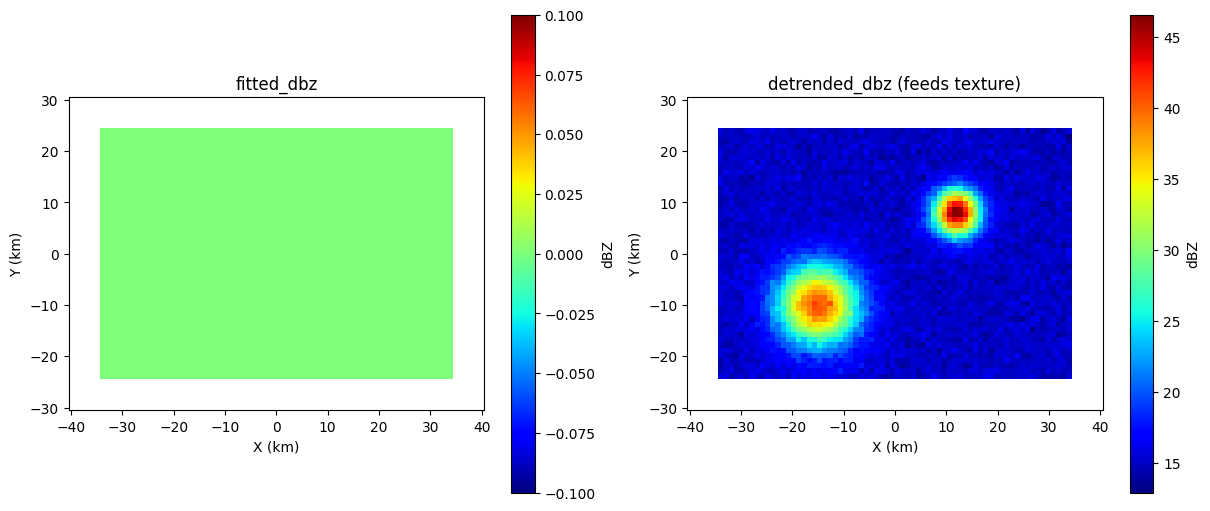

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
pc = axes[0].pcolormesh(x_km, y_km, r_debug.fitted_dbz, cmap="jet", shading="auto")
plt.colorbar(pc, ax=axes[0], label="dBZ")
axes[0].set(title="fitted_dbz", xlabel="X (km)", ylabel="Y (km)")
axes[0].set_aspect("equal")

pc = axes[1].pcolormesh(x_km, y_km, r_debug.detrended_dbz, cmap="jet", shading="auto")
plt.colorbar(pc, ax=axes[1], label="dBZ")
axes[1].set(title="detrended_dbz (feeds texture)", xlabel="X (km)", ylabel="Y (km)")
axes[1].set_aspect("equal")
plt.show()

## 5. Statistics with `eccopy.stats`

No vertical axis here, so the height/depth functions don't apply — but
coverage fractions, clump counts, and physical clump sizes (via
`spacing`) all work.


In [8]:
# Build a spacing array (km/pixel) for physical clump sizes
dy = np.full((ny, nx), y_km[1] - y_km[0])
dx = np.full((ny, nx), x_km[1] - x_km[0])
spacing = np.sqrt(dy * dx)   # geometric mean spacing, km per pixel side

summary = stats.summarize(r_debug.echo_type, spacing=spacing)
for k, v in summary.items():
    if not isinstance(v, np.ndarray):
        print(f"{k}: {v}")
print("Convective clump sizes (km^2):", summary["convective_clump_sizes"])

# Compare against EccoPy-2D-H's own n_clumps (from its dual-threshold clumping stage)
print("Result2DH.n_clumps (algorithm's own count):", r_debug.n_clumps)
print("stats.n_clumps (relabeled from final echo_type):",
      stats.n_clumps(r_debug.echo_type, category="convective"))

n_valid: 3264
stratiform: 0.9267769607843137
mixed: 0.04871323529411765
convective: 0.024509803921568627
convective_pct: 2.450980392156863
stratiform_pct: 92.67769607843137
mixed_pct: 4.8713235294117645
n_convective_clumps: 2
n_stratiform_clumps: 1
mean_convective_clump_size: 41.19287706500749
Convective clump sizes (km^2): [78.266  4.119]
Result2DH.n_clumps (algorithm's own count): 2
stats.n_clumps (relabeled from final echo_type): 2


Note the two clump counts above can differ: `Result2DH.n_clumps` comes
from the dual-threshold clumping algorithm itself (an earlier pipeline
stage, on convectivity), while `stats.n_clumps` re-labels connectivity
on the *final* `echo_type` array. They usually agree but aren't
guaranteed to — see `stats.n_clumps`'s docstring.


## 6. Plotting

Same colormap conventions as the other modules — EccoPy-2D-H always
produces basic (3-code) output, so use `basic_echo_type_cmap()` /
`convectivity_cmap()`.


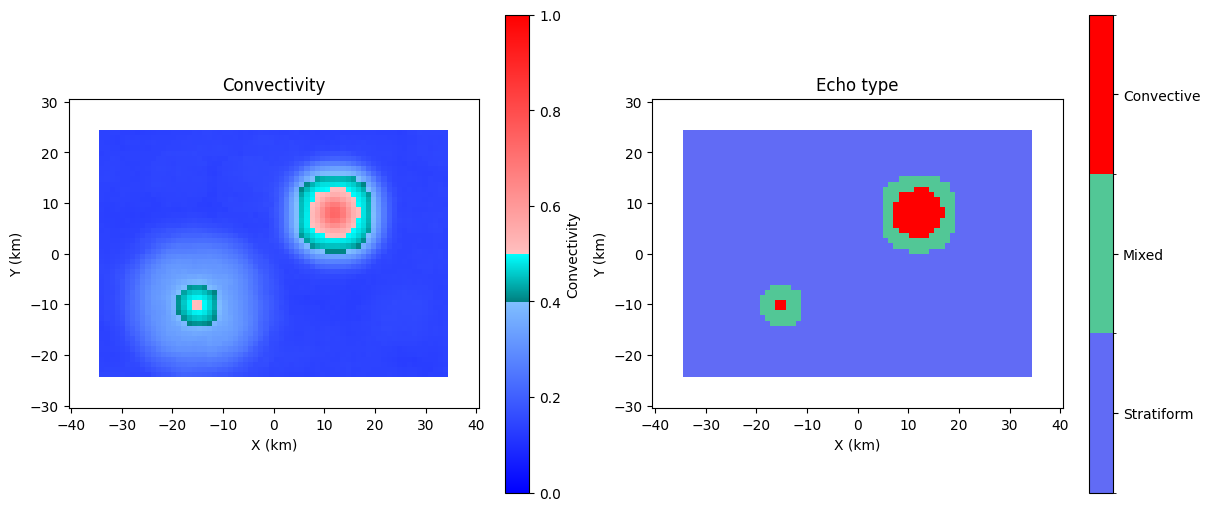

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

pc = axes[0].pcolormesh(x_km, y_km, r_debug.convectivity, cmap=convectivity_cmap(),
                        norm=convectivity_norm(), shading="auto")
plt.colorbar(pc, ax=axes[0], label="Convectivity")
axes[0].set(title="Convectivity", xlabel="X (km)", ylabel="Y (km)")
axes[0].set_aspect("equal")

pc = axes[1].pcolormesh(x_km, y_km, r_debug.echo_type, cmap=basic_echo_type_cmap(),
                        norm=basic_echo_type_norm(), shading="auto")
cb = plt.colorbar(pc, ax=axes[1], ticks=range(1, 4))
cb.ax.set_yticklabels(BASIC_ECHO_TYPE_LABELS)
axes[1].set(title="Echo type", xlabel="X (km)", ylabel="Y (km)")
axes[1].set_aspect("equal")
plt.show()

## Summary

- EccoPy-2D-H classifies a single horizontal level using the same 2-D
  radial texture engine as EccoPy-3D, always returning basic (3-code)
  output.
- `min_convective_area` (km²) is an opt-in size floor for convective
  clumps, analogous to EccoPy-1D's `min_convective_length`.
- `return_intermediates=True` is available but SLOW (a plain Python
  per-point loop) — use it for debugging a specific level, not
  routinely.
- `eccopy.stats` works the same way as the other modules, minus the
  height/depth functions (no vertical axis).

See `eccopy3d_workflow.ipynb` next for the full 3-D volume path, which
combines this module's 2-D radial texture with vertical sub-classification.
